In [ ]:
# Import required libraries
import numpy as np
import cv2
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

In [ ]:
# Image URLs
url1 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQlGd6Q5s9ULcmteHaMHQuP9BkHKkIPiA-hHCo76283YQ&s"
url2 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTYXyKmqbiLwbSJBwn4Txj8lKmzl45JrmnGMJ91pYQT_Q&s=10"

# Download images
response1 = requests.get(url1)
response2 = requests.get(url2)

response1.raise_for_status()
response2.raise_for_status()

# Load images using PIL and convert to RGB
Image1 = Image.open(BytesIO(response1.content)).convert("RGB")
Image2 = Image.open(BytesIO(response2.content)).convert("RGB")

# Convert images to NumPy arrays
Image1 = np.array(Image1)
Image2 = np.array(Image2)

Loading, Inspecting, and Displaying Two Images


In [ ]:
# Inspect image information
print("Image 1")
print("Shape:", Image1.shape)
print("Data type:", Image1.dtype)
print("Minimum pixel value:", Image1.min())
print("Maximum pixel value:", Image1.max())

print("\nImage 2")
print("Shape:", Image2.shape)
print("Data type:", Image2.dtype)
print("Minimum pixel value:", Image2.min())
print("Maximum pixel value:", Image2.max())

Image 1
Shape: (183, 275, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255

Image 2
Shape: (516, 387, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


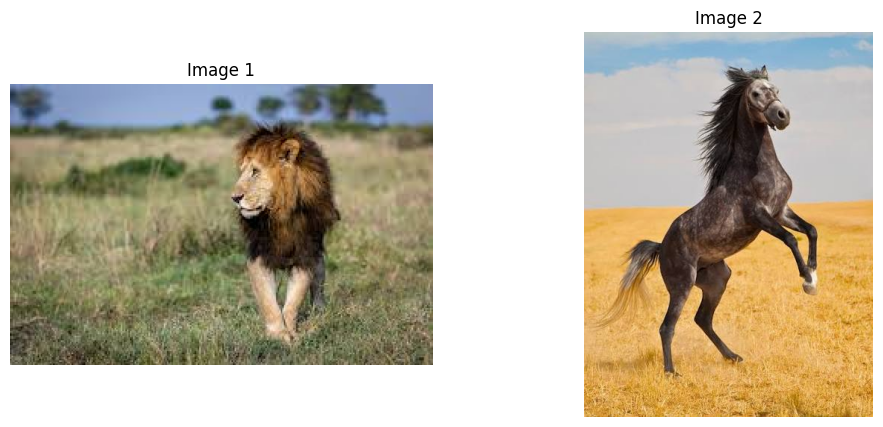

In [ ]:
# Display the two images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Image1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Image2)
plt.title("Image 2")
plt.axis("off")

plt.show()

Direct Pixel-Level / Array-Level Manipulation

In [ ]:
# Make copies so the original images remain unchanged
Image1_array = Image1.copy()
Image2_array = Image2.copy()

# Example of direct array-level pixel manipulation
# Access the RGB values of the first pixel
print("First pixel of Image 1:", Image1_array[0, 0])
print("First pixel of Image 2:", Image2_array[0, 0])

# Display array dimensions
print("\nImage 1 array shape:", Image1_array.shape)
print("Image 2 array shape:", Image2_array.shape)

# Example of array slicing
top_left_region = Image1_array[0:30, 0:30]

print("\nSliced region shape:", top_left_region.shape)

First pixel of Image 1: [115 138 182]
First pixel of Image 2: [184 196 194]

Image 1 array shape: (183, 275, 3)
Image 2 array shape: (516, 387, 3)

Sliced region shape: (30, 30, 3)


Crop Random 30×30 and Paste into Image2

In [ ]:
# Get image dimensions
height1, width1, _ = Image1_array.shape
height2, width2, _ = Image2_array.shape

# Check that both images are large enough
if height1 < 30 or width1 < 30:
    raise ValueError("Image 1 must be at least 30x30 pixels.")

if height2 < 30 or width2 < 30:
    raise ValueError("Image 2 must be at least 30x30 pixels.")

# Create a random number generator
rng = np.random.default_rng()

# Generate random top-left coordinates for the 30x30 crop
crop_y = rng.integers(0, height1 - 30 + 1)
crop_x = rng.integers(0, width1 - 30 + 1)

# Crop a 30x30 region from Image 1 using array slicing
crop_30x30 = Image1_array[
    crop_y:crop_y + 30,
    crop_x:crop_x + 30
]

# Generate a random location in Image 2 for pasting
paste_y = rng.integers(0, height2 - 30 + 1)
paste_x = rng.integers(0, width2 - 30 + 1)

# Create Image3 as a copy of Image2
Image3 = Image2_array.copy()

# Paste the 30x30 crop into Image3
Image3[
    paste_y:paste_y + 30,
    paste_x:paste_x + 30
] = crop_30x30

# Display coordinates and crop information
print("Crop location in Image 1:")
print("Y:", crop_y, "X:", crop_x)

print("\nPaste location in Image 2:")
print("Y:", paste_y, "X:", paste_x)

print("\nCrop shape:", crop_30x30.shape)
print("Image3 shape:", Image3.shape)

Crop location in Image 1:
Y: 26 X: 195

Paste location in Image 2:
Y: 470 X: 334

Crop shape: (30, 30, 3)
Image3 shape: (516, 387, 3)


Display Image3

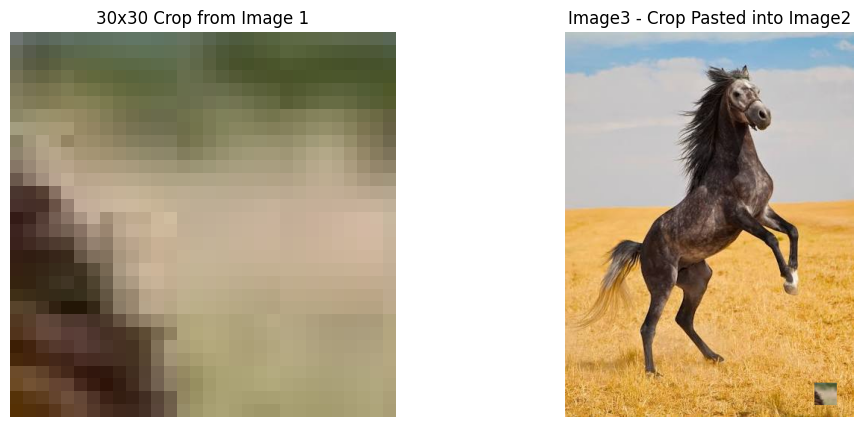

In [ ]:
# Display the cropped region and Image3
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(crop_30x30)
plt.title("30x30 Crop from Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Image3)
plt.title("Image3 - Crop Pasted into Image2")
plt.axis("off")

plt.show()

Convert Both Images and Image3 to Grayscale

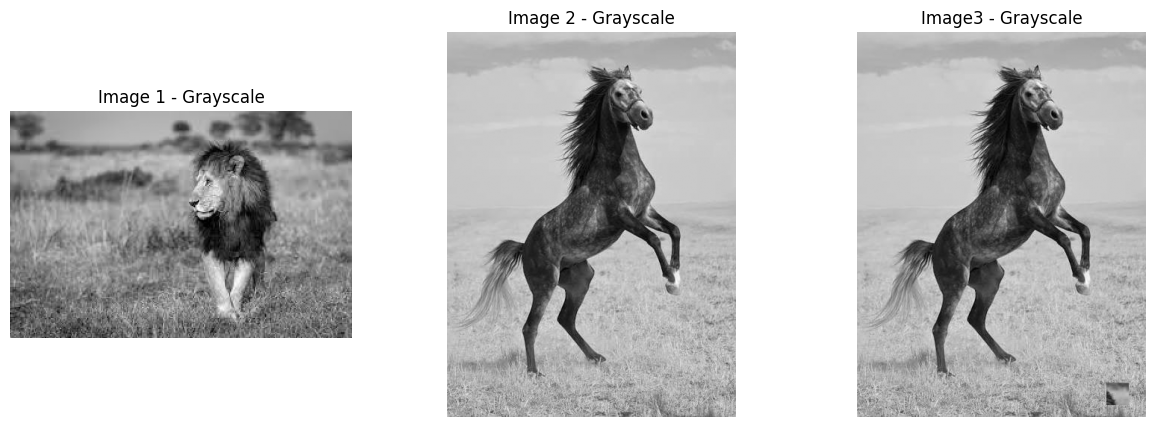

In [ ]:
# Convert Image 1, Image 2, and Image3 to grayscale
Image1_gray = cv2.cvtColor(Image1_array, cv2.COLOR_RGB2GRAY)
Image2_gray = cv2.cvtColor(Image2_array, cv2.COLOR_RGB2GRAY)
Image3_gray = cv2.cvtColor(Image3, cv2.COLOR_RGB2GRAY)

# Display grayscale images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Image1_gray, cmap="gray")
plt.title("Image 1 - Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Image2_gray, cmap="gray")
plt.title("Image 2 - Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Image3_gray, cmap="gray")
plt.title("Image3 - Grayscale")
plt.axis("off")

plt.show()

Apply Sharpening Kernel to Image3

In [ ]:
# Define a sharpening kernel
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# Apply the sharpening kernel to Image3 grayscale
Image3_sharpened = cv2.filter2D(
    Image3_gray,
    ddepth=-1,
    kernel=sharpen_kernel
)

Display the Final Sharpened Image3

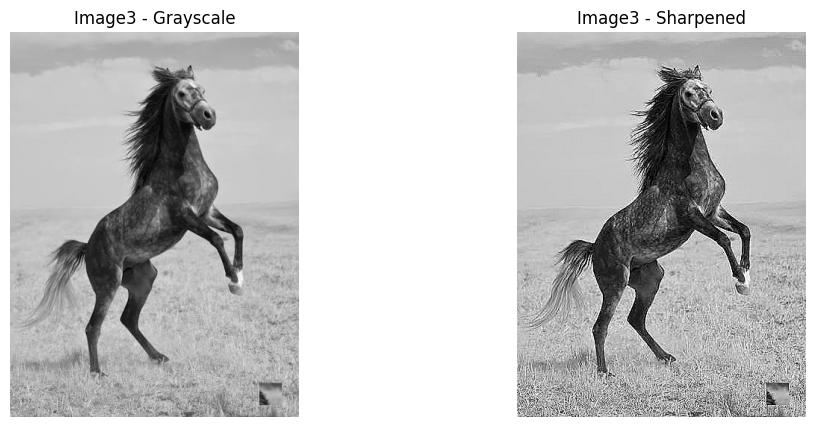

In [ ]:
# Display Image3 before and after sharpening
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Image3_gray, cmap="gray")
plt.title("Image3 - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Image3_sharpened, cmap="gray")
plt.title("Image3 - Sharpened")
plt.axis("off")

plt.show()